# PREDICTIVE MODELING OF CUSTOMER PROMOTION ACCEPTANCE IN SME
*Floriand Beshku -*
*2026*

### PREDICTIVE MODELING OF CUSTOMER PROMOTION ACCEPTANCE: Logistic Regression Analysis

This project demonstrates how data can be used to improve promotional decision-making by replacing intuition-based marketing with an objective, data-driven approach. Using a dataset of 5,000 gym customers, I developed a logistic regression model to predict the probability that a customer will accept a promotional offer.

### Business Context:
Many businesses rely on broad assumptions or intuition when targeting promotions, often resulting in wasted marketing spend and missed opportunities to convert high-potential customers. Systematic targeting is essential to improve conversion rates and justify marketing resources with measurable evidence.

### Objective: 
Predict the likelihood of promotion acceptance and identify the customer characteristics and behaviors that most strongly influence that decision.

### Dataset Overview:
* Volume: 5,000 unique customer records.
* Target Variable: Binary outcome (1 = Accepted, 0 = Did not accept).

### Key Variables: 
Age, income, distance from gym, site visits, App installed, email/SMS engagement, trial class attendance, tour completion, membership status, promotion characteristics (discount size/type), nearby competitors, etc.

### Methodology Workflow

| Step | Phase | Key Task |
| :--- | :--- | :--- |
| **01** | **Preparation** | Data cleaning and conversion of categorical variables to binary indicators. |
| **02** | **Exploration** | Analysis of customer demographics and engagement behavior patterns. |
| **03** | **Modeling** | Logistic regression development to estimate acceptance probabilities. |
| **04** | **Validation** | Data partitioning (Train/Validation/Test) for unbiased evaluation. |
| **05** | **Evaluation** | Performance metrics via confusion matrices and classification reports. |
| **06** | **Diagnostics** | Probability threshold analysis (e.g., 0.50 vs. 0.30) to align with business goals. |
| **07** | **Optimization** | Statistical variable selection (p-values) to simplify the model for deployment.|


### Core Focus: Interpretability. 
While predictive accuracy is critical, this model emphasizes interpretability and strategic flexibility. By producing clear probability scores, the model enables management to rank customers by their likelihood of acceptance and adjust targeting thresholds based on goals like maximizing reach or minimizing costs.


In [3]:
# Environment Setup 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pylab import * 

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import statsmodels.api as sm
from scipy import stats

In [4]:
# Load the data & basic inspection
df = pd.read_csv("gym_promo_customers_5000_i.csv")
# Shape
print("Dataset shape:", df.shape)
# Preview first rows
print("\nFirst 5 rows:")
print(df.head())
# Data types and missing values
print("\nData info:")
print(df.info())

Dataset shape: (5000, 28)

First 5 rows:
  customer_id  age  gender  income_k  distance_miles  commute_minutes student  \
0      C00001   57  Female      39.5             0.5                4      No   
1      C00002   43  Female     108.8             1.3               10     Yes   
2      C00003   33  Female      96.8             8.1               46      No   
3      C00004   25  Female      59.3             1.7                9      No   
4      C00005   56    Male      98.9             6.5               49      No   

        lead_source contact_channel  site_visits_30d  ...  membership_status  \
0          Referral             SMS                4  ...          Cancelled   
1           Walk-in           Phone                8  ...       Never Member   
2  Employer Partner             SMS                6  ...       Never Member   
3        Google Ads           Email                4  ...       Never Member   
4          Referral             SMS                4  ...       Never Me

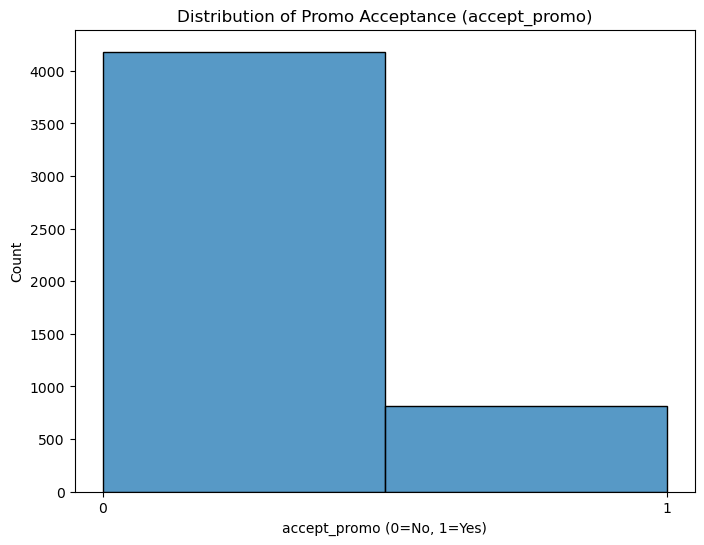

Counts of accept_promo:
accept_promo
0    4182
1     818
Name: count, dtype: int64

Percentages of accept_promo:
accept_promo
0    83.64
1    16.36
Name: proportion, dtype: float64


In [5]:
# Target distribution
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x="accept_promo", bins=2)
plt.title("Distribution of Promo Acceptance (accept_promo)")
plt.xlabel("accept_promo (0=No, 1=Yes)")
plt.ylabel("Count")
plt.xticks([0, 1])
plt.show()

# Display counts
accept_counts = df["accept_promo"].value_counts()
accept_pct = df["accept_promo"].value_counts(normalize=True) * 100

print("Counts of accept_promo:")
print(accept_counts)
print("\nPercentages of accept_promo:")
print(accept_pct.round(2))


In [6]:
# Data preparation ( dummy encoding)
# Drop ID column
df_model = df.drop(columns=["customer_id"])
# Automatically identify categorical columns
cat_vars = df_model.select_dtypes(include=["object"]).columns.tolist()
# Remove target from the list if it appears as object (just in case)
if "accept_promo" in cat_vars:
    cat_vars.remove("accept_promo")
print("Categorical columns detected:", cat_vars)

# Create dummy variables for all categorical predictors
df_model = pd.get_dummies(df_model, columns=cat_vars, drop_first=True)

# Safety check: confirm no object columns remain (besides none)
print("\nObject columns remaining after encoding:",
      df_model.select_dtypes(include=["object"]).columns.tolist())

print("\nPrepared dataset shape:", df_model.shape)
print(df_model.head())

Categorical columns detected: ['gender', 'student', 'lead_source', 'contact_channel', 'app_installed', 'trial_class_attended', 'tours_completed', 'prior_member', 'membership_status', 'price_sensitivity', 'fitness_goal', 'preferred_time', 'promo_type', 'competitor_nearby']

Object columns remaining after encoding: []

Prepared dataset shape: (5000, 39)
   age  income_k  distance_miles  commute_minutes  site_visits_30d  \
0   57      39.5             0.5                4                4   
1   43     108.8             1.3               10                8   
2   33      96.8             8.1               46                6   
3   25      59.3             1.7                9                4   
4   56      98.9             6.5               49                4   

   emails_opened_30d  sms_clicked_30d  past_classes_90d  \
0                  2                1                 0   
1                  2                1                 2   
2                  1                2           

In [7]:
# Define target + predictors, then Train/Val/Test split (50/30/20)

target = "accept_promo"

# Features = everything except the target
features = df_model.drop(columns=[target])
target_variable = df_model[target]

# First split out TEST (20%)
X_train, X_test, y_train, y_test = train_test_split(
    features, target_variable,
    test_size=0.20,
    random_state=42,
    stratify=target_variable
)

# Split remaining TRAIN (80%) into Train (50%) and Validation (30%)
# 0.375 * 0.80 = 0.30 overall
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.375,
    random_state=42,
    stratify=y_train
)

print("Training set shape:", X_train.shape, y_train.shape)
print("Validation set shape:", X_val.shape, y_val.shape)
print("Test set shape:", X_test.shape, y_test.shape)
print("\nAcceptance rate (Train):", round(y_train.mean(), 3))
print("Acceptance rate (Val):  ", round(y_val.mean(), 3))
print("Acceptance rate (Test): ", round(y_test.mean(), 3))

Training set shape: (2500, 38) (2500,)
Validation set shape: (1500, 38) (1500,)
Test set shape: (1000, 38) (1000,)

Acceptance rate (Train): 0.164
Acceptance rate (Val):   0.163
Acceptance rate (Test):  0.164


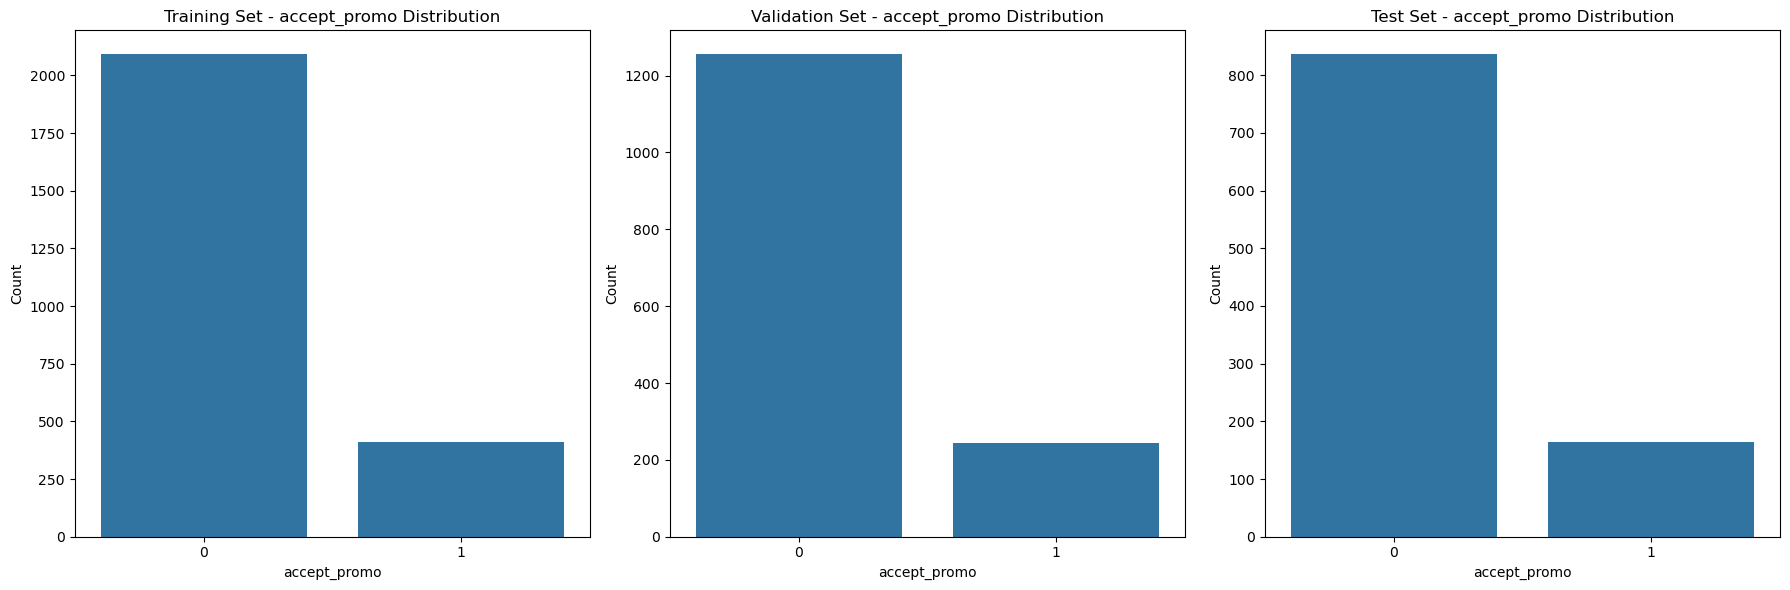

Training set accept_promo counts and percentages:
accept_promo
0    2091
1     409
Name: count, dtype: int64
accept_promo
0    83.64
1    16.36
Name: proportion, dtype: float64

Validation set accept_promo counts and percentages:
accept_promo
0    1255
1     245
Name: count, dtype: int64
accept_promo
0    83.67
1    16.33
Name: proportion, dtype: float64

Test set accept_promo counts and percentages:
accept_promo
0    836
1    164
Name: count, dtype: int64
accept_promo
0    83.6
1    16.4
Name: proportion, dtype: float64


In [8]:
# Plot target distribution across Train/Val/Test
train_data = X_train.copy()
train_data["accept_promo"] = y_train

val_data = X_val.copy()
val_data["accept_promo"] = y_val

test_data = X_test.copy()
test_data["accept_promo"] = y_test

fig, axs = plt.subplots(1, 3, figsize=(18, 6))

sns.countplot(data=train_data, x="accept_promo", ax=axs[0])
axs[0].set_title("Training Set - accept_promo Distribution")
axs[0].set_xlabel("accept_promo")
axs[0].set_ylabel("Count")
axs[0].set_xticks([0, 1])

sns.countplot(data=val_data, x="accept_promo", ax=axs[1])
axs[1].set_title("Validation Set - accept_promo Distribution")
axs[1].set_xlabel("accept_promo")
axs[1].set_ylabel("Count")
axs[1].set_xticks([0, 1])

sns.countplot(data=test_data, x="accept_promo", ax=axs[2])
axs[2].set_title("Test Set - accept_promo Distribution")
axs[2].set_xlabel("accept_promo")
axs[2].set_ylabel("Count")
axs[2].set_xticks([0, 1])

plt.tight_layout()
plt.show()

# Print counts and percentages
def counts_and_pct(series):
    counts = series.value_counts()
    pct = series.value_counts(normalize=True) * 100
    return counts, pct

train_counts, train_pct = counts_and_pct(train_data["accept_promo"])
val_counts, val_pct = counts_and_pct(val_data["accept_promo"])
test_counts, test_pct = counts_and_pct(test_data["accept_promo"])

print("Training set accept_promo counts and percentages:")
print(train_counts)
print(train_pct.round(2))

print("\nValidation set accept_promo counts and percentages:")
print(val_counts)
print(val_pct.round(2))

print("\nTest set accept_promo counts and percentages:")
print(test_counts)
print(test_pct.round(2))


In [9]:
# Train Logistic Regression model (baseline)
logistic_model = LogisticRegression(random_state=42, max_iter=2000)
logistic_model.fit(X_train, y_train)
print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [10]:
# Predictions (classes) + predicted probabilities

# Predicted classes
y_train_pred = logistic_model.predict(X_train)
y_val_pred   = logistic_model.predict(X_val)
y_test_pred  = logistic_model.predict(X_test)

# Predicted probabilities for class 1 (accept_promo = 1)
y_train_proba = logistic_model.predict_proba(X_train)[:, 1]
y_val_proba   = logistic_model.predict_proba(X_val)[:, 1]
y_test_proba  = logistic_model.predict_proba(X_test)[:, 1]

print("Predictions (classes and probabilities) made successfully.")
print("\nSample predicted probabilities (first 10, Test):")
print(pd.Series(y_test_proba).head(10).round(4))


Predictions (classes and probabilities) made successfully.

Sample predicted probabilities (first 10, Test):
0    0.0942
1    0.0318
2    0.6745
3    0.0450
4    0.0581
5    0.4625
6    0.0854
7    0.3566
8    0.0449
9    0.0971
dtype: float64


In [11]:
# Actual vs Probability vs Predicted Class (first 10 test rows)

results_df = pd.DataFrame({
    "Actual": y_test.head(10).tolist(),
    "Predicted Probability (accept_promo=1)": y_test_proba[:10].tolist(),
    "Predicted Class": y_test_pred[:10].tolist()
})

print("Actuals, Probabilities, and Predicted accept_promo (First 10 rows of Test Set):")
display(results_df)

Actuals, Probabilities, and Predicted accept_promo (First 10 rows of Test Set):


,Actual,Predicted Probability (accept_promo=1),Predicted Class
0,0,0.094157,0
1,0,0.031758,0
2,1,0.674523,1
3,0,0.044969,0
4,0,0.058062,0
5,0,0.462525,0
6,0,0.085366,0
7,0,0.356601,0
8,0,0.044932,0
9,1,0.097118,0


In [12]:
# Inspect predictions near the 0.5 cutoff
uncertain_idx = (y_test_proba >= 0.45) & (y_test_proba <= 0.55)

uncertain_df = pd.DataFrame({
    "Actual": y_test[uncertain_idx],
    "Predicted Probability (accept_promo=1)": y_test_proba[uncertain_idx],
    "Predicted Class": y_test_pred[uncertain_idx]
})

print("Test Set rows with predicted probability between 0.45 and 0.55:")
display(uncertain_df.head(10))

print("\nNumber of such cases:", len(uncertain_df))

Test Set rows with predicted probability between 0.45 and 0.55:


,Actual,Predicted Probability (accept_promo=1),Predicted Class
42,0,0.462525,0
2688,1,0.482037,0
2928,0,0.515582,1
3384,1,0.473697,0
584,1,0.479957,0
4468,1,0.459750,0
4581,1,0.485444,0
2820,0,0.487450,0
1067,1,0.497139,0
2888,1,0.498520,0



Number of such cases: 29


In [13]:
# Coefficients + Logistic Regression Formula
# Extract coefficients and intercept

feature_names = X_train.columns
coefficients = logistic_model.coef_[0]
intercept = logistic_model.intercept_[0]

# Create coefficient table
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Add intercept
intercept_df = pd.DataFrame({
    "Feature": ["Intercept"],
    "Coefficient": [intercept]
})

coef_df = pd.concat([intercept_df, coef_df], ignore_index=True)

print("Logistic Regression Coefficients (including Intercept):")
print(coef_df)

# Logistic Regression Formula

linear_combination = f"{intercept:.4f}"
for i, feature in enumerate(feature_names):
    linear_combination += f" + {coefficients[i]:.4f}*{feature}"

formula = f"p = 1 / (1 + exp(-({linear_combination})))"

print("\nLogistic Regression Formula (probability of accept_promo = 1):")
print(formula)


Logistic Regression Coefficients (including Intercept):
                           Feature  Coefficient
0                        Intercept    -3.582312
1                              age     0.003036
2                         income_k     0.009359
3                   distance_miles     0.004675
4                  commute_minutes    -0.022529
5                  site_visits_30d    -0.018427
6                emails_opened_30d     0.093035
7                  sms_clicked_30d     0.164597
8                 past_classes_90d     0.091878
9       time_since_last_visit_days    -0.023522
10                    discount_pct     0.027167
11              satisfaction_score     0.111062
12               monthly_spend_usd    -0.000755
13                     gender_Male    -0.260534
14                     student_Yes     0.006432
15          lead_source_Google Ads     0.081593
16           lead_source_Instagram     0.001818
17               lead_source_Other     0.187346
18            lead_source_Referr

Confusion Matrix - Training Set:
[[2055   36]
 [ 330   79]]

Confusion Matrix - Validation Set:
[[1223   32]
 [ 212   33]]

Confusion Matrix - Test Set:
[[821  15]
 [139  25]]


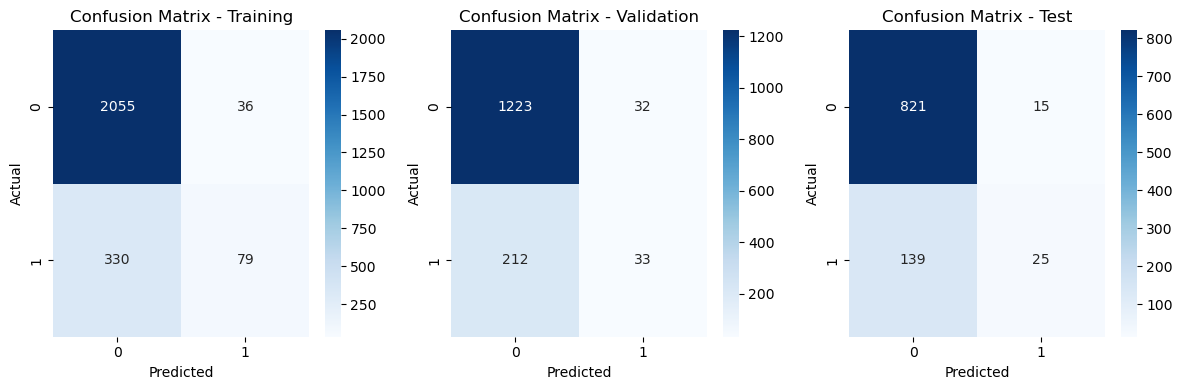

In [14]:
# Confusion matrices (Train / Validation / Test)

cm_train = confusion_matrix(y_train, y_train_pred)
cm_val   = confusion_matrix(y_val, y_val_pred)
cm_test  = confusion_matrix(y_test, y_test_pred)

print("Confusion Matrix - Training Set:")
print(cm_train)

print("\nConfusion Matrix - Validation Set:")
print(cm_val)

print("\nConfusion Matrix - Test Set:")
print(cm_test)

# Visualize confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

sns.heatmap(cm_train, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Confusion Matrix - Training")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_val, annot=True, fmt="d", cmap="Blues", ax=axes[1])
axes[1].set_title("Confusion Matrix - Validation")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

sns.heatmap(cm_test, annot=True, fmt="d", cmap="Blues", ax=axes[2])
axes[2].set_title("Confusion Matrix - Test")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [15]:
# Classification reports

print("Classification Report - Training Set:")
print(classification_report(y_train, y_train_pred))

print("\nClassification Report - Validation Set:")
print(classification_report(y_val, y_val_pred))

print("\nClassification Report - Test Set:")
print(classification_report(y_test, y_test_pred))


Classification Report - Training Set:
              precision    recall  f1-score   support

           0       0.86      0.98      0.92      2091
           1       0.69      0.19      0.30       409

    accuracy                           0.85      2500
   macro avg       0.77      0.59      0.61      2500
weighted avg       0.83      0.85      0.82      2500


Classification Report - Validation Set:
              precision    recall  f1-score   support

           0       0.85      0.97      0.91      1255
           1       0.51      0.13      0.21       245

    accuracy                           0.84      1500
   macro avg       0.68      0.55      0.56      1500
weighted avg       0.80      0.84      0.80      1500


Classification Report - Test Set:
              precision    recall  f1-score   support

           0       0.86      0.98      0.91       836
           1       0.62      0.15      0.25       164

    accuracy                           0.85      1000
   macro avg  

In [16]:
# Change classification threshold to 0.30
# Set new threshold
threshold = 0.30

# Apply threshold to probabilities
y_train_pred_30 = (y_train_proba >= threshold).astype(int)
y_val_pred_30 = (y_val_proba >= threshold).astype(int)
y_test_pred_30 = (y_test_proba >= threshold).astype(int)

print(f"New classification threshold set to {threshold}")


New classification threshold set to 0.3


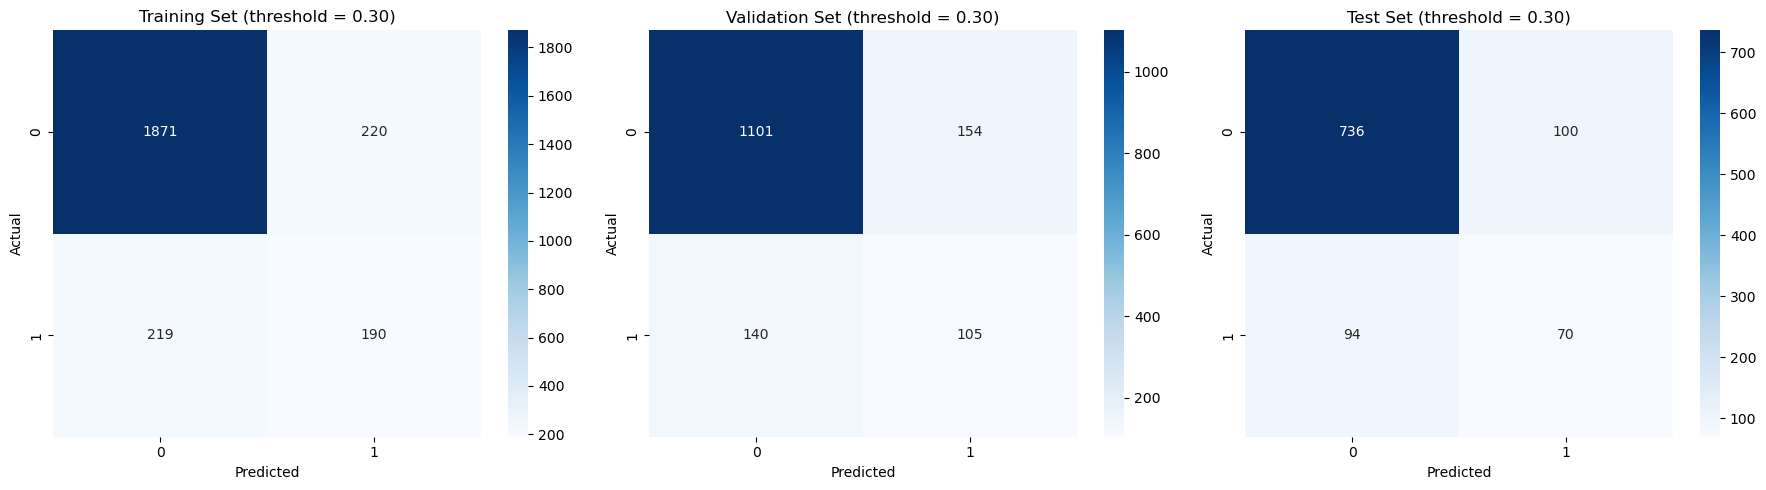

In [17]:
# Confusion Matrices + Heatmaps (threshold = 0.30)

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

threshold = 0.30

# Predictions using threshold = 0.30
y_train_pred_30 = (y_train_proba >= threshold).astype(int)
y_val_pred_30   = (y_val_proba   >= threshold).astype(int)
y_test_pred_30  = (y_test_proba  >= threshold).astype(int)
# Confusion matrices
cm_train_30 = confusion_matrix(y_train, y_train_pred_30)
cm_val_30   = confusion_matrix(y_val, y_val_pred_30)
cm_test_30  = confusion_matrix(y_test, y_test_pred_30)

# Plot heatmaps
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(cm_train_30, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Training Set (threshold = 0.30)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
sns.heatmap(cm_val_30, annot=True, fmt="d", cmap="Blues", ax=axes[1])
axes[1].set_title("Validation Set (threshold = 0.30)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
sns.heatmap(cm_test_30, annot=True, fmt="d", cmap="Blues", ax=axes[2])
axes[2].set_title("Test Set (threshold = 0.30)")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")

plt.tight_layout()
plt.show()


In [18]:
# Variable Selection using Statistical Significance (p-values)
# Review p-values to identify significant predictors

import statsmodels.api as sm

# Make sure all columns are numeric (booleans -> 0/1) for statsmodels
X_train_sm = X_train.copy()
X_val_sm   = X_val.copy()
X_test_sm  = X_test.copy()

for col in X_train_sm.columns:
    if X_train_sm[col].dtype == bool:
        X_train_sm[col] = X_train_sm[col].astype(int)
        X_val_sm[col]   = X_val_sm[col].astype(int)
        X_test_sm[col]  = X_test_sm[col].astype(int)

# Add intercept term (constant)
X_train_sm = sm.add_constant(X_train_sm)

# Fit logistic regression using statsmodels
logit_model = sm.Logit(y_train, X_train_sm)
result = logit_model.fit(disp=False)

# Show full summary (includes p-values)
print(result.summary())


                           Logit Regression Results                           
Dep. Variable:           accept_promo   No. Observations:                 2500
Model:                          Logit   Df Residuals:                     2462
Method:                           MLE   Df Model:                           37
Date:                Tue, 17 Mar 2026   Pseudo R-squ.:                  0.1878
Time:                        20:51:35   Log-Likelihood:                -904.81
converged:                       True   LL-Null:                       -1114.0
Covariance Type:            nonrobust   LLR p-value:                 4.254e-66
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                             -2.4127   5.02e+06  -4.81e-07      1.000   -9.84e+06    9.84e+06
age                                0.0030      0.004      0.683      0.

In [19]:
# Create a clean p-value table (sorted)

pvals = result.pvalues.sort_values()
coefs = result.params

pval_table = pd.DataFrame({
    "feature": pvals.index,
    "coef": coefs[pvals.index].values,
    "p_value": pvals.values
})

print("P-values (sorted):")
print(pval_table)


P-values (sorted):
                           feature      coef       p_value
0       time_since_last_visit_days -0.023584  7.064708e-23
1         trial_class_attended_Yes  0.948717  6.283668e-14
2              tours_completed_Yes  0.779823  6.721659e-08
3                         income_k  0.009365  5.158461e-05
4                 past_classes_90d  0.092070  1.966153e-04
5                  sms_clicked_30d  0.166634  1.755152e-03
6             lead_source_Referral  0.673625  2.737955e-03
7            price_sensitivity_Med -0.397135  6.164331e-03
8                     discount_pct  0.026922  1.031460e-02
9      membership_status_Cancelled  0.580095  1.141242e-02
10              satisfaction_score  0.111329  1.250944e-02
11                 commute_minutes -0.022546  2.089307e-02
12               emails_opened_30d  0.094152  2.488601e-02
13                     gender_Male -0.266474  2.844373e-02
14           competitor_nearby_Yes -0.272653  3.071259e-02
15             lead_source_Walk-in  0

In [20]:
# Select significant variables (example: p < 0.05)

alpha = 0.05

significant_features = pval_table.loc[pval_table["p_value"] < alpha, "feature"].tolist()

# Ensure const stays in the model
if "const" not in significant_features:
    significant_features = ["const"] + significant_features

print("Significant features (p < 0.05):")
print(significant_features)
print("\nNumber of significant features:", len(significant_features) - 1)


Significant features (p < 0.05):
['const', 'time_since_last_visit_days', 'trial_class_attended_Yes', 'tours_completed_Yes', 'income_k', 'past_classes_90d', 'sms_clicked_30d', 'lead_source_Referral', 'price_sensitivity_Med', 'discount_pct', 'membership_status_Cancelled', 'satisfaction_score', 'commute_minutes', 'emails_opened_30d', 'gender_Male', 'competitor_nearby_Yes']

Number of significant features: 15


In [21]:
# Refit simplified model using selected features
# Evaluate performance again

reduced_features = [f for f in significant_features if f != "const"]

X_train_red = X_train[reduced_features].copy()
X_val_red   = X_val[reduced_features].copy()
X_test_red  = X_test[reduced_features].copy()

# Train sklearn logistic regression on reduced feature set
logistic_model_red = LogisticRegression(random_state=42, max_iter=2000)
logistic_model_red.fit(X_train_red, y_train)

print("Reduced Logistic Regression model trained successfully.")
print("Number of features used:", X_train_red.shape[1])


Reduced Logistic Regression model trained successfully.
Number of features used: 15


=== Reduced Model (threshold = 0.50) ===

Confusion Matrix - Test:
[[821  15]
 [135  29]]

Classification Report - Test:
              precision    recall  f1-score   support

           0       0.86      0.98      0.92       836
           1       0.66      0.18      0.28       164

    accuracy                           0.85      1000
   macro avg       0.76      0.58      0.60      1000
weighted avg       0.83      0.85      0.81      1000



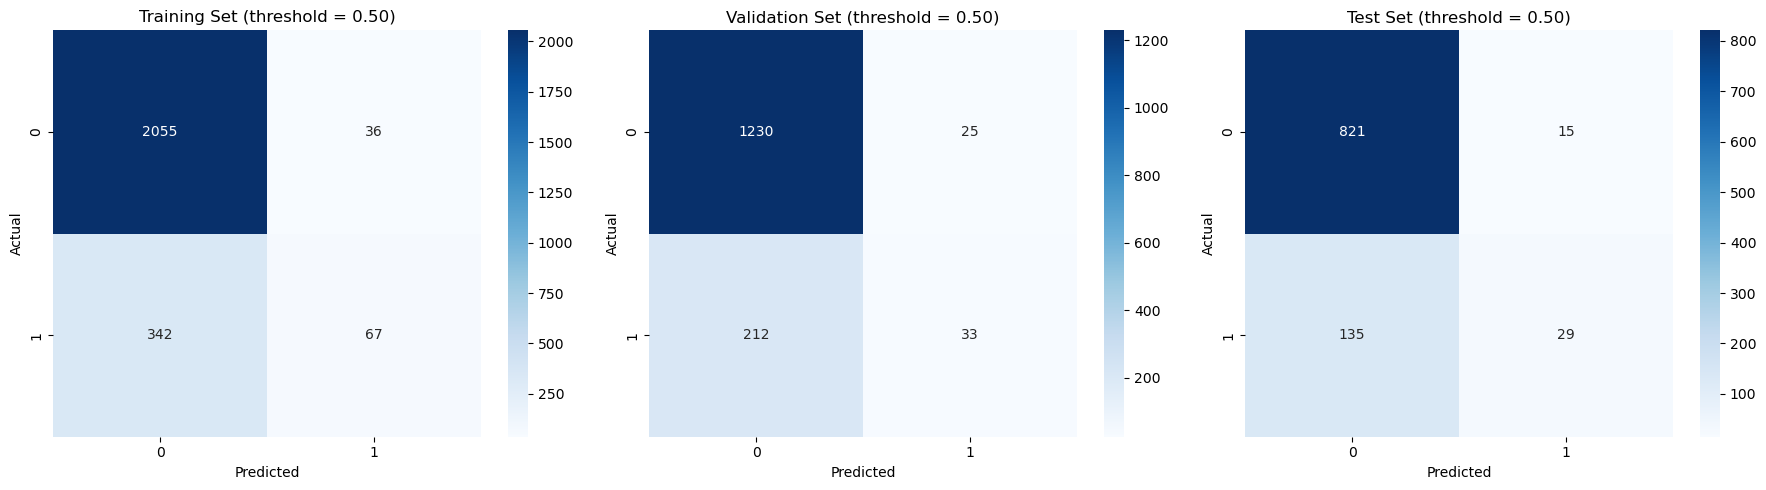


=== Reduced Model (threshold = 0.30) ===

Confusion Matrix - Test:
[[736 100]
 [ 94  70]]

Classification Report - Test:
              precision    recall  f1-score   support

           0       0.89      0.88      0.88       836
           1       0.41      0.43      0.42       164

    accuracy                           0.81      1000
   macro avg       0.65      0.65      0.65      1000
weighted avg       0.81      0.81      0.81      1000



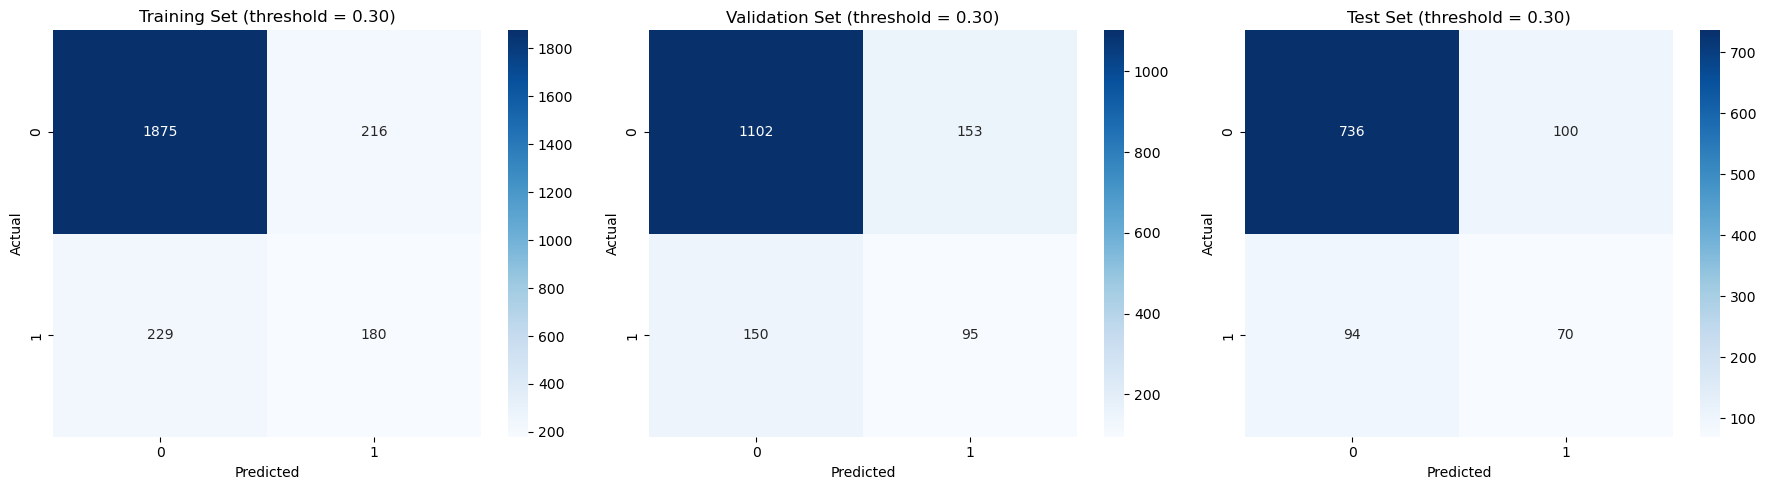

In [22]:
# Evaluate reduced model (Confusion Matrices + Reports + Heatmaps)
# Use BOTH default threshold 0.50 and business threshold 0.30

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Predicted probabilities
y_train_proba_red = logistic_model_red.predict_proba(X_train_red)[:, 1]
y_val_proba_red   = logistic_model_red.predict_proba(X_val_red)[:, 1]
y_test_proba_red  = logistic_model_red.predict_proba(X_test_red)[:, 1]

# Threshold = 0.50 (Default)
y_train_pred_red_50 = (y_train_proba_red >= 0.50).astype(int)
y_val_pred_red_50   = (y_val_proba_red   >= 0.50).astype(int)
y_test_pred_red_50  = (y_test_proba_red  >= 0.50).astype(int)

cm_train_50 = confusion_matrix(y_train, y_train_pred_red_50)
cm_val_50   = confusion_matrix(y_val, y_val_pred_red_50)
cm_test_50  = confusion_matrix(y_test, y_test_pred_red_50)

print("=== Reduced Model (threshold = 0.50) ===")
print("\nConfusion Matrix - Test:")
print(cm_test_50)
print("\nClassification Report - Test:")
print(classification_report(y_test, y_test_pred_red_50))

# Heatmaps (0.50)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(cm_train_50, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Training Set (threshold = 0.50)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_val_50, annot=True, fmt="d", cmap="Blues", ax=axes[1])
axes[1].set_title("Validation Set (threshold = 0.50)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

sns.heatmap(cm_test_50, annot=True, fmt="d", cmap="Blues", ax=axes[2])
axes[2].set_title("Test Set (threshold = 0.50)")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")

plt.tight_layout()
plt.show()

# Threshold = 0.30 (Business Threshold)
threshold = 0.30

y_train_pred_red_30 = (y_train_proba_red >= threshold).astype(int)
y_val_pred_red_30   = (y_val_proba_red   >= threshold).astype(int)
y_test_pred_red_30  = (y_test_proba_red  >= threshold).astype(int)

cm_train_30 = confusion_matrix(y_train, y_train_pred_red_30)
cm_val_30   = confusion_matrix(y_val, y_val_pred_red_30)
cm_test_30  = confusion_matrix(y_test, y_test_pred_red_30)

print("\n=== Reduced Model (threshold = 0.30) ===")
print("\nConfusion Matrix - Test:")
print(cm_test_30)
print("\nClassification Report - Test:")
print(classification_report(y_test, y_test_pred_red_30))

# Heatmaps (0.30)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(cm_train_30, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Training Set (threshold = 0.30)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_val_30, annot=True, fmt="d", cmap="Blues", ax=axes[1])
axes[1].set_title("Validation Set (threshold = 0.30)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

sns.heatmap(cm_test_30, annot=True, fmt="d", cmap="Blues", ax=axes[2])
axes[2].set_title("Test Set (threshold = 0.30)")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [23]:
# Logistic Regression Formula (Reduced Model)
# Using only statistically significant variables
# Extracting coefficients and intercept from reduced model

reduced_feature_names = X_train_red.columns
reduced_coefficients = logistic_model_red.coef_[0]
reduced_intercept = logistic_model_red.intercept_[0]

# Create coefficient table
coef_red_df = pd.DataFrame({
    "Feature": reduced_feature_names,
    "Coefficient": reduced_coefficients
})

print("Reduced Logistic Regression Coefficients:")
print(coef_red_df)

print("\nIntercept:", reduced_intercept)

# Build logistic regression probability formula

linear_term = f"{reduced_intercept:.4f}"

for feature, coef in zip(reduced_feature_names, reduced_coefficients):
    sign = "+" if coef >= 0 else "-"
    linear_term += f" {sign} {abs(coef):.4f}*{feature}"

formula_reduced = f"p = 1 / (1 + exp(-({linear_term})))"

print("\nReduced Logistic Regression Formula (probability of accept_promo = 1):")
print(formula_reduced)


Reduced Logistic Regression Coefficients:
                        Feature  Coefficient
0    time_since_last_visit_days    -0.023458
1      trial_class_attended_Yes     0.943426
2           tours_completed_Yes     0.741440
3                      income_k     0.009429
4              past_classes_90d     0.094654
5               sms_clicked_30d     0.154896
6          lead_source_Referral     0.509454
7         price_sensitivity_Med    -0.290678
8                  discount_pct     0.032915
9   membership_status_Cancelled     0.915997
10           satisfaction_score     0.112466
11              commute_minutes    -0.021601
12            emails_opened_30d     0.085371
13                  gender_Male    -0.242198
14        competitor_nearby_Yes    -0.255168

Intercept: -3.493273671656133

Reduced Logistic Regression Formula (probability of accept_promo = 1):
p = 1 / (1 + exp(-(-3.4933 - 0.0235*time_since_last_visit_days + 0.9434*trial_class_attended_Yes + 0.7414*tours_completed_Yes + 0.0094*